# **Import Libraries**

In [118]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')


# **Read Dataset**




In [119]:
train=pd.read_csv('/content/train.csv')
test =pd.read_csv('/content/test.csv')

# **Understand data**

In [120]:
train.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [121]:
train.tail()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
690083,690083,at-risk,6.31,69.7,24.11,2157.0,NaN,30.8,3.00,non-veg,high,poor,active,yes,female
690084,690084,at-risk,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,veg,medium,average,moderate,no,male
690085,690085,fit,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,non-veg,NaN,average,active,no,male
690086,690086,at-risk,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,balanced,NaN,average,active,yes,male
690087,690087,at-risk,5.55,69.3,24.38,2257.0,5144.0,47.9,1.76,balanced,medium,average,moderate,yes,male


In [122]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  object 
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  object 
 10  stress_level             607277 non-null  object 
 11  sleep_quality            631757 non-null  object 
 12  physical_activity_level  653467 non-null  object 
 13  smoking_alcohol          661506 non-null  object 
 14  gend

In [123]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,690088.0,345043.500000,199211.390620,0.0,172521.75,345043.50,517565.25,690087.00
sleep_duration,614089.0,6.992597,1.215407,3.0,6.16,6.99,7.81,10.00
heart_rate,682255.0,75.096504,8.175106,50.0,69.40,75.10,80.70,107.70
bmi,676190.0,22.984925,2.481787,16.0,21.32,22.99,24.66,34.82
calorie_expenditure,637235.0,2226.084931,347.532098,1200.0,2053.00,2241.00,2456.00,3580.00
step_count,676172.0,8615.953050,3929.399831,1002.0,5389.00,8856.00,12114.00,14999.00
exercise_duration,683187.0,38.751456,14.742189,0.0,29.20,39.40,49.40,99.80
water_intake,646611.0,2.188542,0.518489,0.5,1.84,2.17,2.50,4.72


# **Check Duplicate Rows**

In [124]:
print("Duplicate Rows :",
      train.duplicated().sum())

Duplicate Rows : 0


In [125]:
train = train.drop_duplicates()

# **Check Missing Values**

In [126]:
missing = train.isnull().sum()
missing = missing[missing>0]
missing.sort_values(ascending=False)

,0
stress_level,82811
sleep_duration,75999
sleep_quality,58331
calorie_expenditure,52853
water_intake,43477
physical_activity_level,36621
smoking_alcohol,28582
gender,21373
step_count,13916
bmi,13898


In [127]:
train_id = train['id']
test_id = test['id']

# **Target Variable Analysis**

In [128]:
train['health_condition'].value_counts()

,count
health_condition,
at-risk,592561
unhealthy,57724
fit,39803


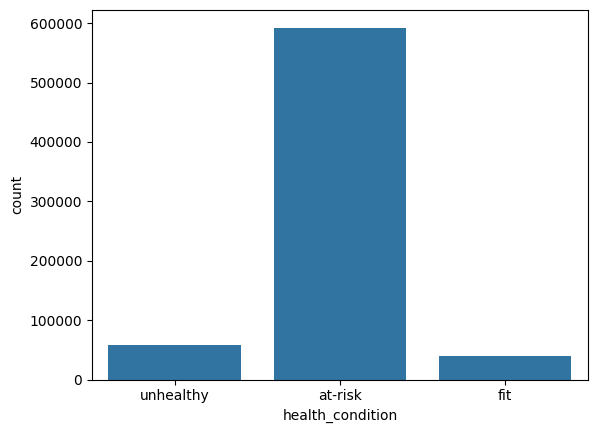

In [129]:
sns.countplot(data=train,x='health_condition')
plt.show()

# **Numerical Feature EDA**

# **Distribution:**

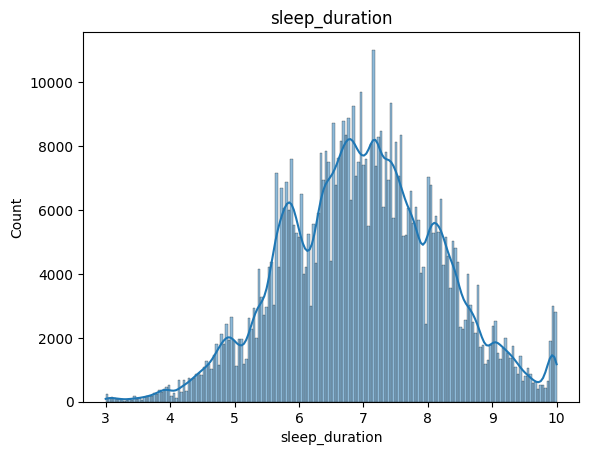

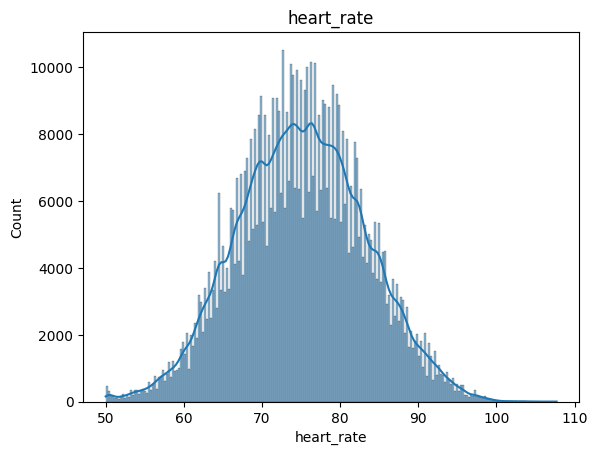

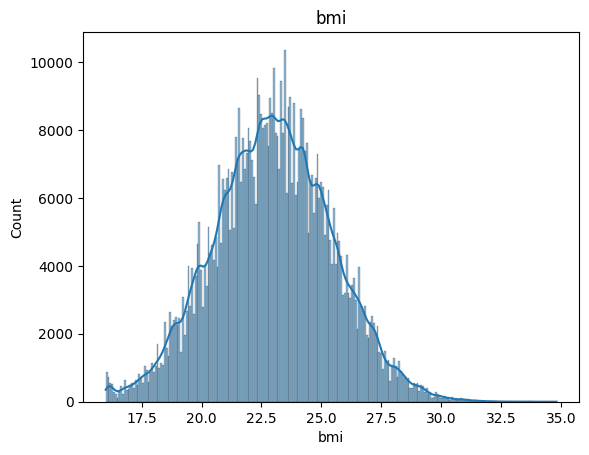

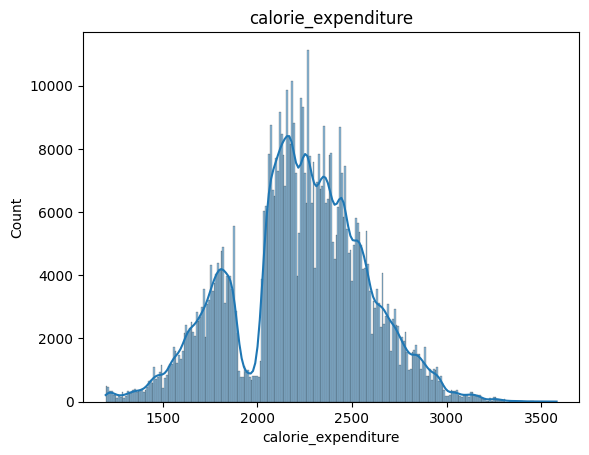

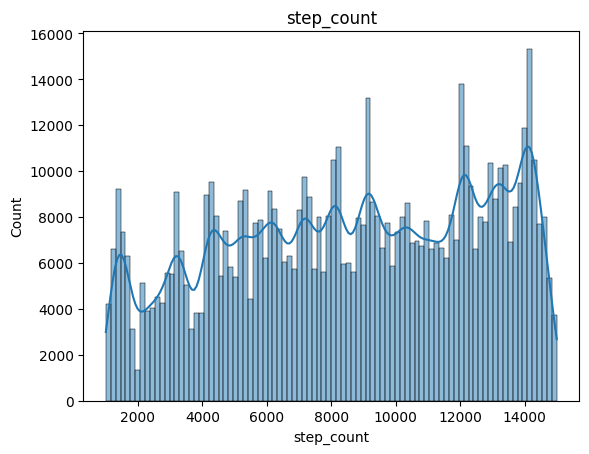

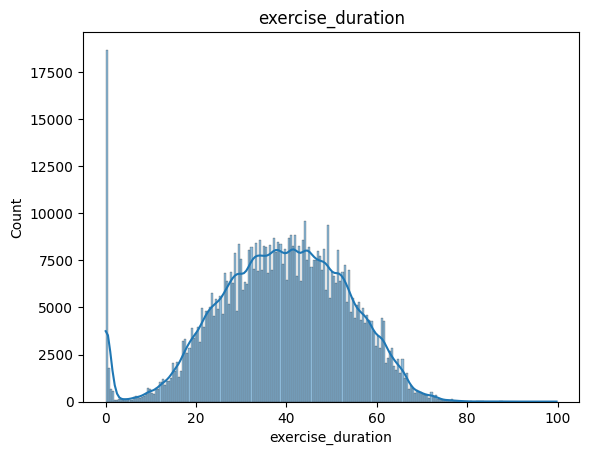

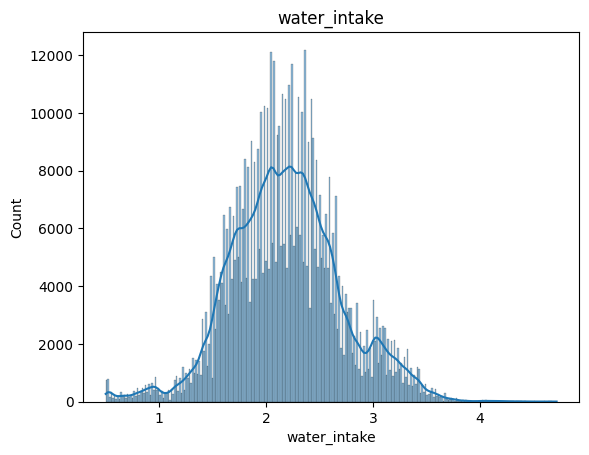

In [130]:
num_cols = ['sleep_duration','heart_rate','bmi','calorie_expenditure','step_count','exercise_duration','water_intake']
for col in num_cols:
  sns.histplot(train[col],kde=True)
  plt.title(col)
  plt.show()

# **Boxplots:**

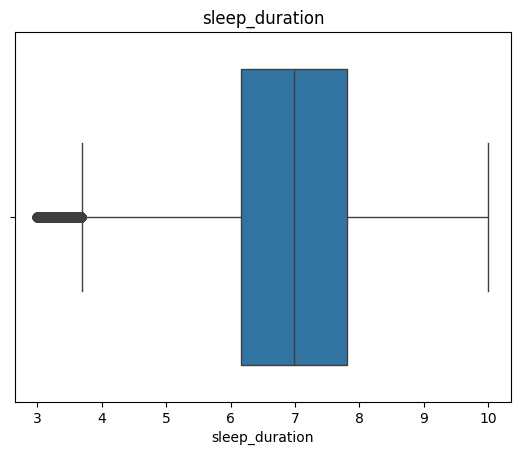

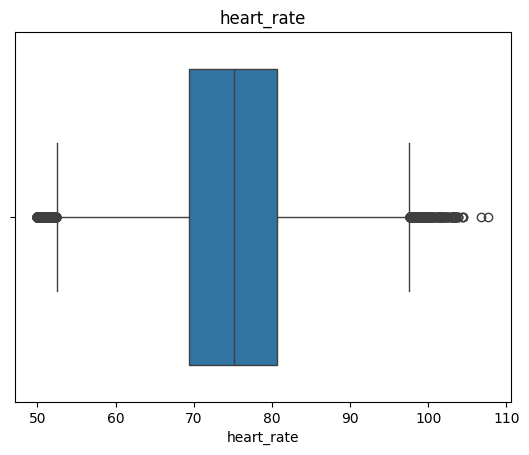

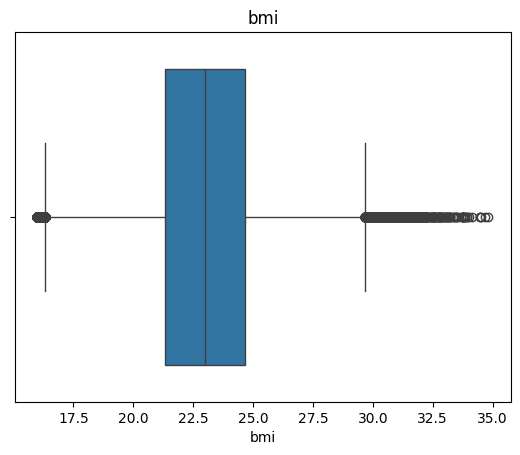

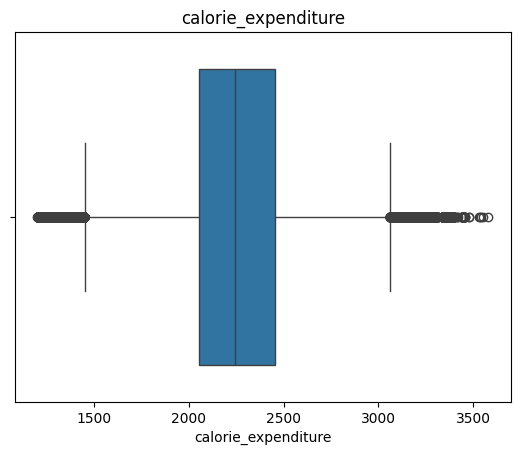

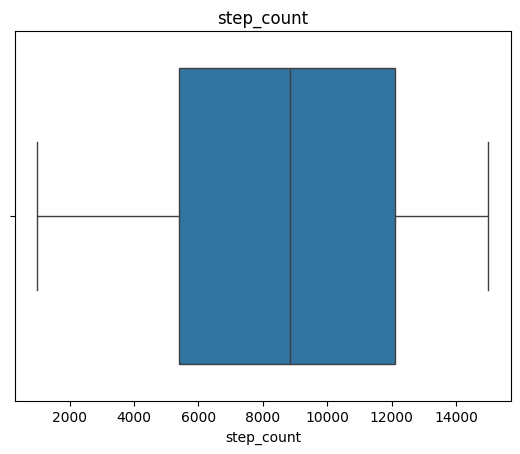

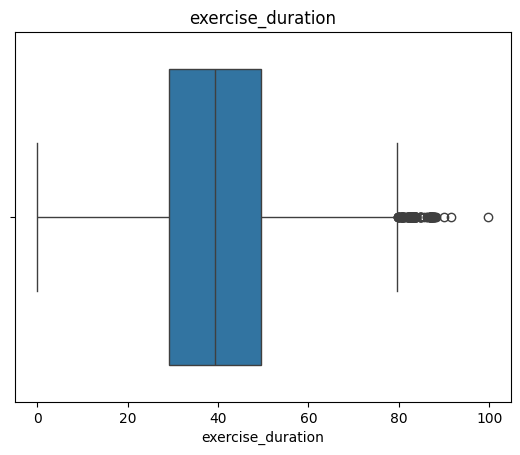

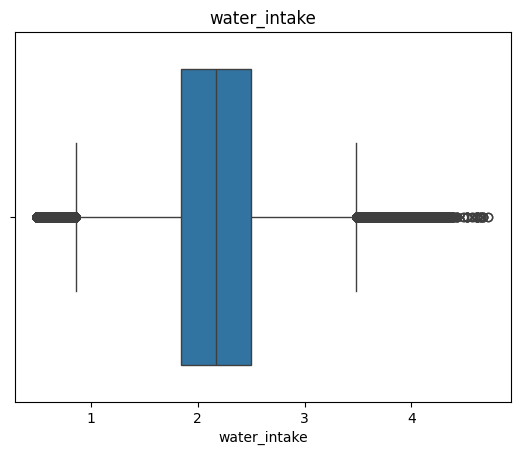

In [131]:
for col in num_cols:
  sns.boxplot(x=train[col])
  plt.title(col)
  plt.show()

# **Categorical EDA**

In [132]:
cat_cols = ['diet_type','stress_level','sleep_quality','physical_activity_level','smoking_alcohol','gender']

Distribution

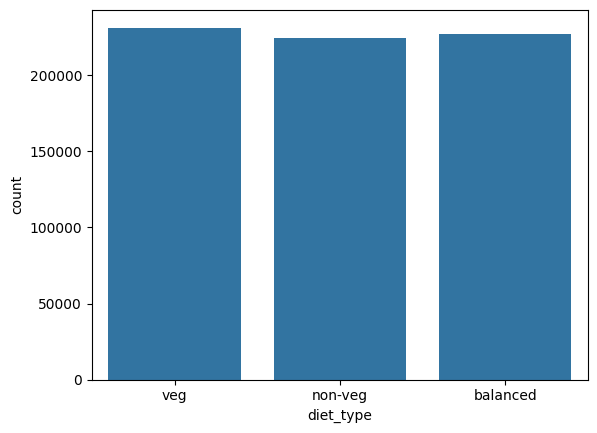

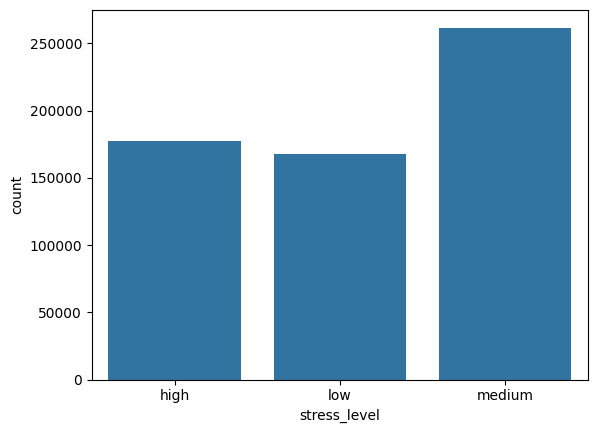

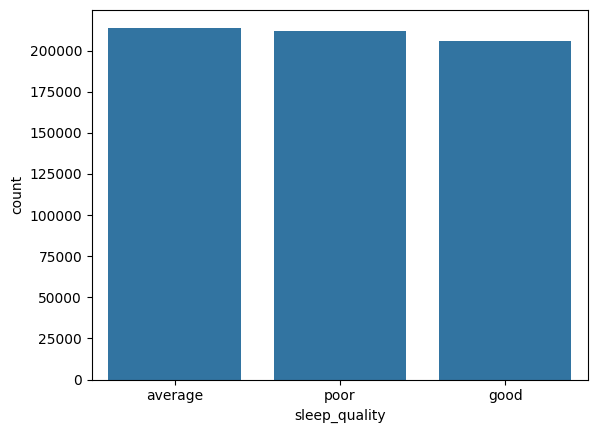

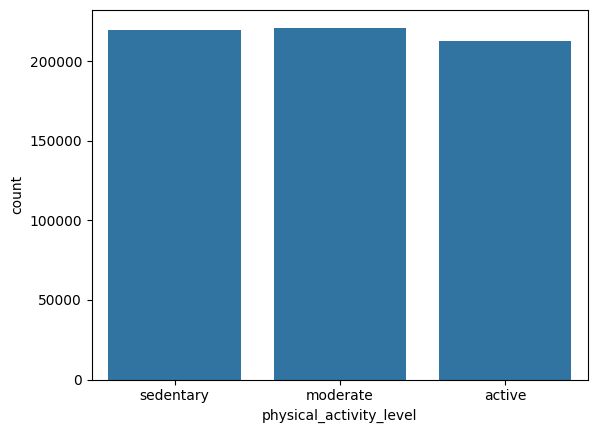

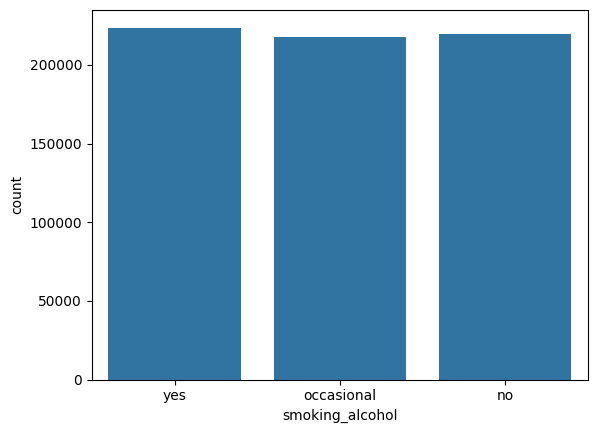

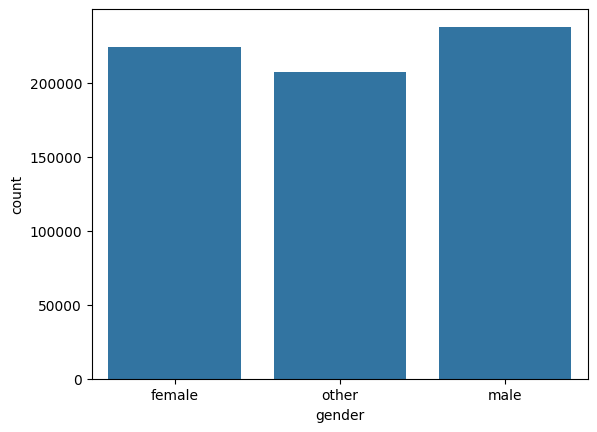

In [133]:
for col in cat_cols:
  sns.countplot(data=train,x=col)
  plt.show()

Feature vs Target

# **Stress Level vs Health Condition**

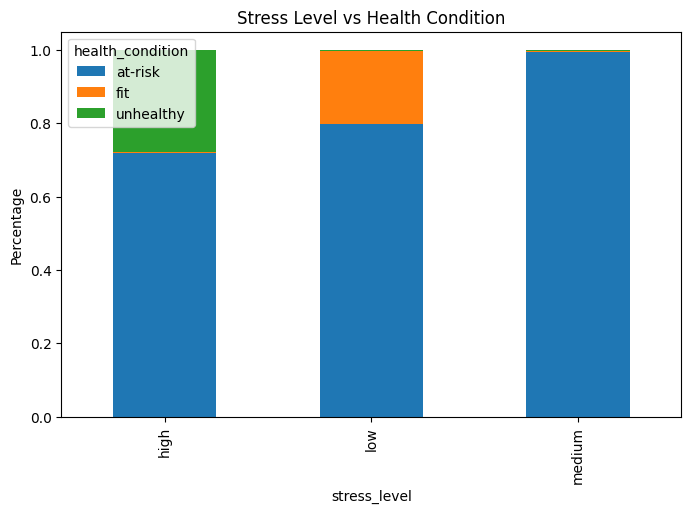

In [134]:
pd.crosstab(train['stress_level'],train['health_condition'],normalize='index').plot(kind='bar',stacked=True,figsize=(8,5))
plt.title('Stress Level vs Health Condition')
plt.ylabel('Percentage')
plt.show()

# **Sleep Quality vs Health Condition**

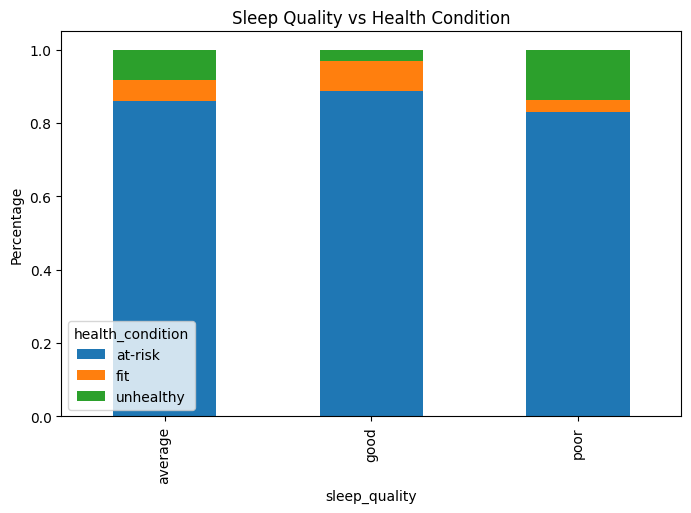

In [135]:
pd.crosstab(train['sleep_quality'],train['health_condition'],normalize='index').plot(kind='bar',stacked=True,figsize=(8,5))
plt.title('Sleep Quality vs Health Condition')
plt.ylabel('Percentage')
plt.show()

# **Physical Activity Level vs Health Condition**

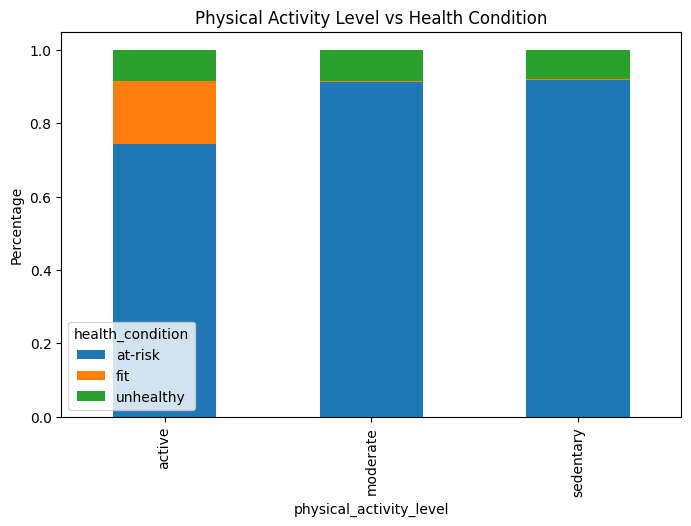

In [136]:
pd.crosstab(train['physical_activity_level'],train['health_condition'],normalize='index').plot(kind='bar',stacked=True,figsize=(8,5))
plt.title('Physical Activity Level vs Health Condition')
plt.ylabel('Percentage')
plt.show()

# **Smoking / Alcohol vs Health Condition**

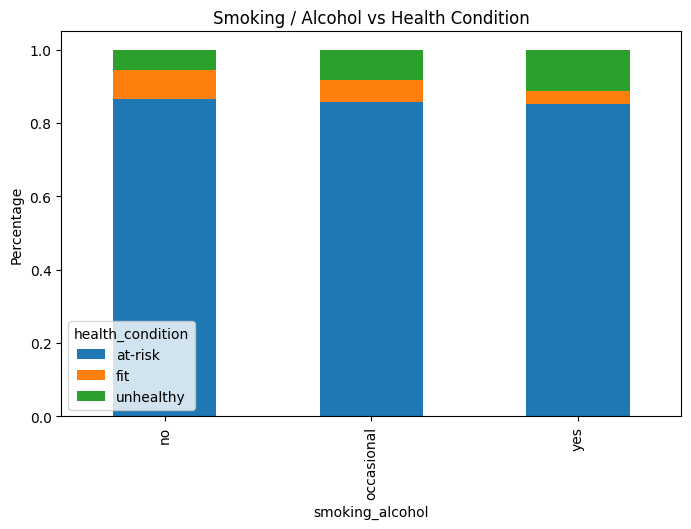

In [137]:
pd.crosstab(train['smoking_alcohol'],train['health_condition'],normalize='index').plot(kind='bar',stacked=True,figsize=(8,5))
plt.title('Smoking / Alcohol vs Health Condition')
plt.ylabel('Percentage')
plt.show()

# **Diet Type vs Health Condition**

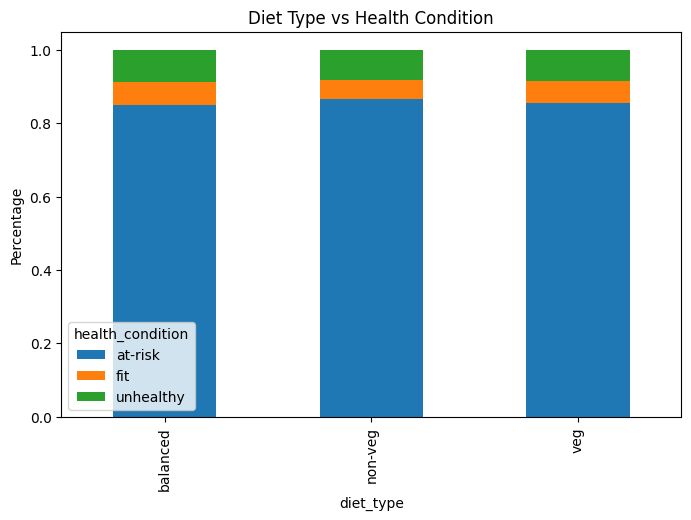

In [138]:
pd.crosstab(train['diet_type'],train['health_condition'],normalize='index').plot(kind='bar',stacked=True,figsize=(8,5))
plt.title('Diet Type vs Health Condition')
plt.ylabel('Percentage')
plt.show()

# **Gender vs Health Condition**

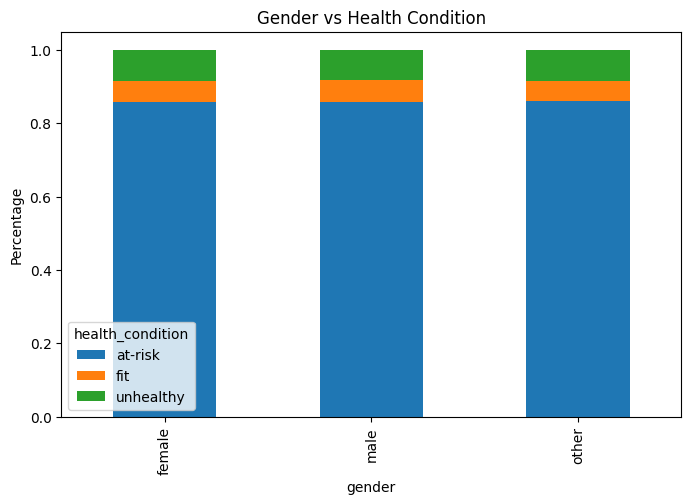

In [139]:
pd.crosstab(train['gender'],train['health_condition'],normalize='index').plot(kind='bar',stacked=True,figsize=(8,5))
plt.title('Gender vs Health Condition')
plt.ylabel('Percentage')
plt.show()

# **Check Duplicate Rows**

In [140]:
print("Duplicate Rows :", train.duplicated().sum())
train = train.drop_duplicates()


Duplicate Rows : 0


# **Check Unique Values**

In [141]:
cat_cols = ['diet_type','stress_level','sleep_quality','physical_activity_level','smoking_alcohol','gender']
for col in cat_cols:
    print(f"\n{col}")
    print(train[col].value_counts(dropna=False))


diet_type
diet_type
veg         231432
balanced    226888
non-veg     224867
NaN           6901
Name: count, dtype: int64

stress_level
stress_level
medium    261819
high      177750
low       167708
NaN        82811
Name: count, dtype: int64

sleep_quality
sleep_quality
average    213948
poor       212166
good       205643
NaN         58331
Name: count, dtype: int64

physical_activity_level
physical_activity_level
moderate     221041
sedentary    219784
active       212642
NaN           36621
Name: count, dtype: int64

smoking_alcohol
smoking_alcohol
yes           223730
no            219791
occasional    217985
NaN            28582
Name: count, dtype: int64

gender
gender
male      237756
female    224016
other     206943
NaN        21373
Name: count, dtype: int64


# **Missing Value Treatment**

Numerical Features

In [142]:
num_cols = ['sleep_duration','heart_rate','bmi','calorie_expenditure','step_count','exercise_duration','water_intake']
for col in num_cols:
  median_value = train[col].median()
  train[col] = train[col].fillna(median_value)
  test[col] = test[col].fillna(median_value)

Categorical Features

In [143]:
for col in cat_cols:
  train[col] = train[col].fillna("Unknown")
  test[col] = test[col].fillna("Unknown")

# **Verify Missing Values**

In [144]:
train.isnull().sum().sum()

np.int64(0)

In [145]:
test.isnull().sum().sum()

np.int64(0)

# **Outlier Analysis**

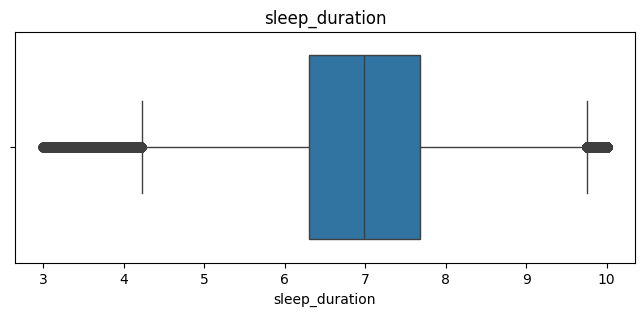

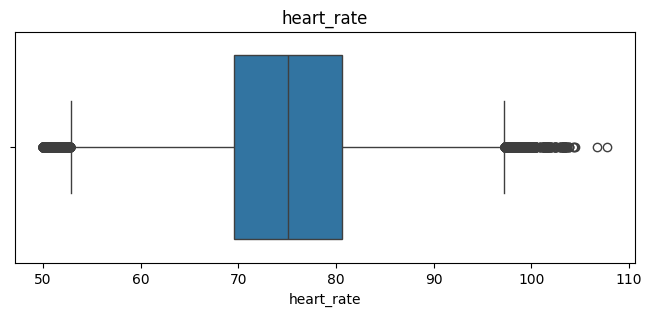

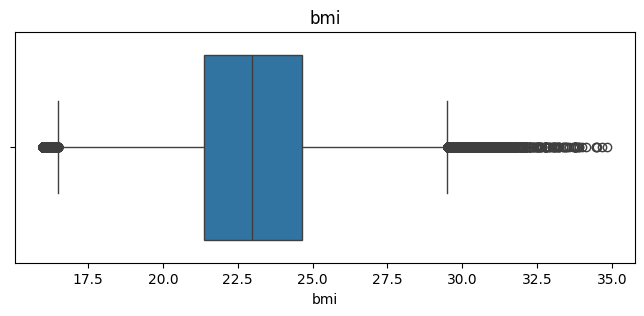

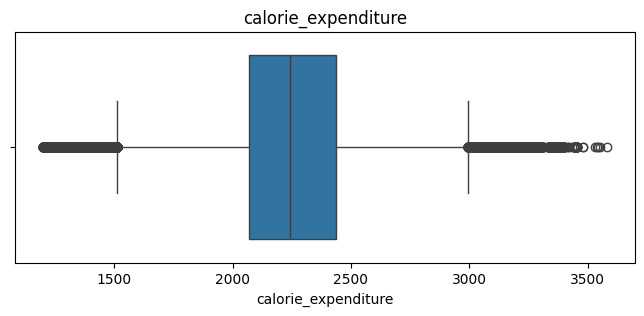

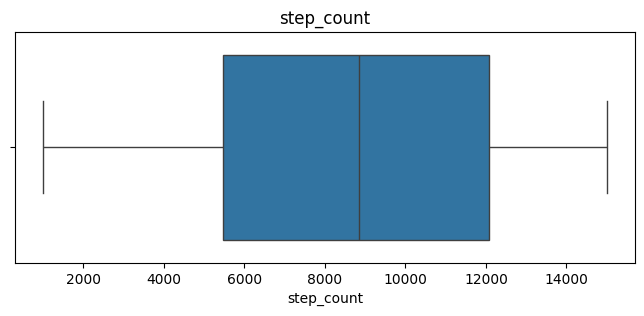

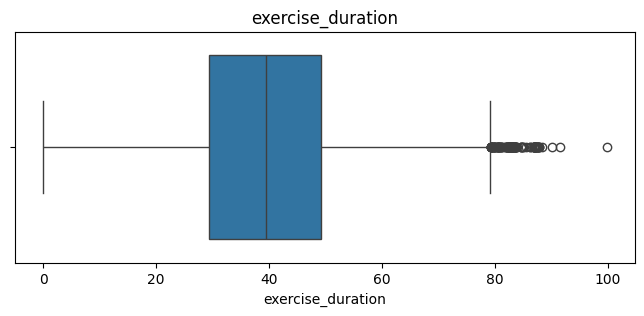

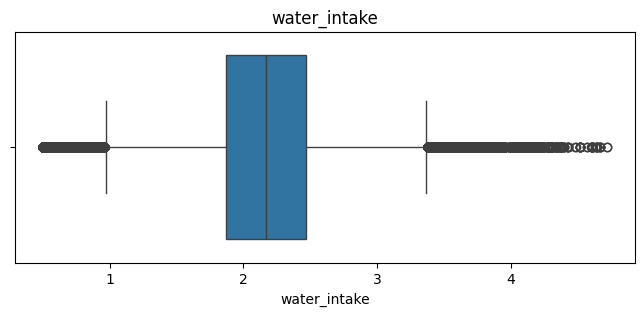

In [146]:
for col in num_cols:
  plt.figure(figsize=(8,3))
  sns.boxplot(x=train[col])
  plt.title(col)
  plt.show()

# **Feature Engineering**

BMI Category

In [147]:
def bmi_category(x):
  if x < 18.5:
    return "Underweight"
  elif x < 25:
    return "Normal"
  elif x < 30:
    return "Overweight"
    return "Obese"

In [148]:
train['bmi_category'] = train['bmi'].apply(bmi_category)
test['bmi_category'] = test['bmi'].apply(bmi_category)

Activity Score

In [149]:
train['activity_score'] = (train['step_count'] * train['exercise_duration'])
test['activity_score'] = (test['step_count']  * test['exercise_duration'])

Calories Per Step

In [150]:
train['calories_per_step'] = (train['calorie_expenditure'] /(train['step_count'] + 1))
test['calories_per_step'] = (test['calorie_expenditure'] / (test['step_count'] + 1))

Water Per Exercise

In [151]:
train['water_per_exercise'] = (train['water_intake'] / (train['exercise_duration'] + 1))
test['water_per_exercise'] = (test['water_intake'] / (test['exercise_duration'] + 1))

Sleep Quality Score

In [152]:
sleep_map = {'poor':1,'average':2,'good':3,'Unknown':2}
train['sleep_quality_score'] = (train['sleep_quality'].map(sleep_map))
test['sleep_quality_score'] = (test['sleep_quality'].map(sleep_map))

Sleep Score

In [153]:
train['sleep_score'] = (train['sleep_duration'] * train['sleep_quality_score'])
test['sleep_score'] = (test['sleep_duration'] * test['sleep_quality_score'])

Health Risk Score

In [154]:
train['health_risk_score'] = (train['heart_rate'] + train['bmi']-train['sleep_duration'])
test['health_risk_score'] = (test['heart_rate'] + test['bmi'] - test['sleep_duration'])

# **Check Newly Created Features**

In [155]:
new_features = ['activity_score','calories_per_step','water_per_exercise','sleep_score','health_risk_score']
train[new_features].head()

,activity_score,calories_per_step,water_per_exercise,sleep_score,health_risk_score
0,26254.8,1.638282,0.089423,10.44,91.04
1,493560.9,0.198746,0.024754,11.06,91.61
2,541629.6,0.189069,0.040921,5.29,94.65
3,429722.6,0.366551,0.033169,9.40,95.63
4,302864.0,0.388762,0.047872,14.46,94.61


# **Feature Importance Before Modeling**

In [156]:
train[new_features].describe().T

,count,mean,std,min,25%,50%,75%,max
activity_score,690088.0,358748.999709,235673.080261,0.000000,163155.375000,327875.750000,529645.800000,1.419256e+06
calories_per_step,690088.0,0.364365,0.311655,0.112893,0.194167,0.252957,0.387247,2.597453e+00
water_per_exercise,690088.0,0.122328,0.356342,0.006977,0.041463,0.054137,0.074483,4.340000e+00
sleep_score,690088.0,14.221004,6.633106,3.000000,7.260000,13.980000,19.920000,3.000000e+01
health_risk_score,690088.0,91.089260,8.598271,57.410000,85.210000,91.070000,96.940000,1.273600e+02


# **Remove Unwanted Columns**

In [157]:
X = train.drop(columns=['id','health_condition'])
y = train['health_condition']

In [158]:
test_model = test.drop(columns=['id'])

# **Define Features and Target**

In [159]:
X = train.drop(columns=['id','health_condition'])
y = train['health_condition']

# **Train Validation Split**

In [160]:
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [161]:
print("X_train :", X_train.shape)
print("X_valid :", X_valid.shape)

print("y_train :", y_train.shape)
print("y_valid :", y_valid.shape)

X_train : (552070, 20)
X_valid : (138018, 20)
y_train : (552070,)
y_valid : (138018,)


# **Identify Categorical Features**

In [162]:
cat_features = X_train.select_dtypes(include='object').columns.tolist()
print(cat_features)

['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender', 'bmi_category']


In [163]:
pip install catboost

In [164]:
from catboost import CatBoostClassifier

# **Create Model**

In [165]:
model = CatBoostClassifier(iterations=1000,learning_rate=0.05,depth=8,loss_function='MultiClass',eval_metric='TotalF1',random_state=42,verbose=100)

# **Train Model**

In [167]:
X_train.isnull().sum().sort_values(ascending=False)

,0
bmi_category,1398
sleep_duration,0
bmi,0
heart_rate,0
calorie_expenditure,0
step_count,0
water_intake,0
exercise_duration,0
stress_level,0
sleep_quality,0


In [168]:
X_valid.isnull().sum().sort_values(ascending=False)

,0
bmi_category,324
sleep_duration,0
bmi,0
heart_rate,0
calorie_expenditure,0
step_count,0
water_intake,0
exercise_duration,0
stress_level,0
sleep_quality,0


# **Check Categorical Columns Specifically**

In [169]:
for col in cat_features:
  print(col)
  print(X_train[col].isnull().sum())
  print("----------------")

diet_type
0
----------------
stress_level
0
----------------
sleep_quality
0
----------------
physical_activity_level
0
----------------
smoking_alcohol
0
----------------
gender
0
----------------
bmi_category
1398
----------------


# **Fix All Categorical Columns**

In [170]:
for col in cat_features:
  X_train[col] = (X_train[col].fillna('Unknown').astype(str))
  X_valid[col] = (X_valid[col].fillna('Unknown').astype(str))
  test_model[col] = (test_model[col].fillna('Unknown').astype(str))

In [171]:
train['sleep_quality'].unique()

array(['average', 'poor', 'Unknown', 'good'], dtype=object)

In [172]:
sleep_map = {'poor':1,'average':2,'good':3,'Unknown':2}

In [173]:
train['sleep_quality'].value_counts(dropna=False)

,count
sleep_quality,
average,213948
poor,212166
good,205643
Unknown,58331


In [174]:
train['sleep_quality_score'].isnull().sum()

np.int64(0)

# **Fix Sleep Quality Mapping**

In [175]:
train['sleep_quality'] = (train['sleep_quality'].astype(str).str.lower())
test['sleep_quality'] = (test['sleep_quality'].astype(str).str.lower())

In [176]:
sleep_map = {'poor':1,'average':2,'good':3,'unknown':2}
train['sleep_quality_score'] = (train['sleep_quality'].map(sleep_map))
test['sleep_quality_score'] = (test['sleep_quality'].map(sleep_map))

# **Find All Columns Having Nulls**

In [177]:
X_train.columns[X_train.isnull().any()]
X_valid.columns[X_valid.isnull().any()]

Index([], dtype='object')

In [178]:
X_train.isnull().sum()[X_train.isnull().sum() > 0]

,0


In [179]:
model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    loss_function='MultiClass',
    eval_metric='TotalF1',
    random_state=42,
    verbose=30
)

# **Train the Model**

In [180]:
model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_valid, y_valid),
    early_stopping_rounds=30
)

0:	learn: 0.9350198	test: 0.9369016	best: 0.9369016 (0)	total: 3.64s	remaining: 18m 8s
30:	learn: 0.9620719	test: 0.9627862	best: 0.9627862 (30)	total: 1m 50s	remaining: 15m 56s
60:	learn: 0.9643328	test: 0.9648976	best: 0.9649364 (58)	total: 3m 34s	remaining: 14m
90:	learn: 0.9647698	test: 0.9653573	best: 0.9653858 (85)	total: 5m 16s	remaining: 12m 6s
120:	learn: 0.9649214	test: 0.9654555	best: 0.9654555 (120)	total: 6m 55s	remaining: 10m 14s
150:	learn: 0.9651400	test: 0.9655830	best: 0.9655830 (150)	total: 8m 34s	remaining: 8m 27s
180:	learn: 0.9653776	test: 0.9656784	best: 0.9657411 (174)	total: 10m 17s	remaining: 6m 45s
210:	learn: 0.9655879	test: 0.9657264	best: 0.9657774 (204)	total: 12m 5s	remaining: 5m 6s
240:	learn: 0.9656872	test: 0.9658105	best: 0.9658387 (237)	total: 13m 48s	remaining: 3m 22s
270:	learn: 0.9658177	test: 0.9658276	best: 0.9658607 (262)	total: 15m 31s	remaining: 1m 39s
299:	learn: 0.9660208	test: 0.9659255	best: 0.9659521 (289)	total: 17m 11s	remaining: 0us


CatBoostClassifier(depth=6, eval_metric='TotalF1', iterations=300, learning_rate=0.1, loss_function='MultiClass', random_state=42, verbose=30)

# **Make Validation Predictions**

In [181]:
pred_valid = model.predict(X_valid)

In [182]:
print(pred_valid.shape)

(138018, 1)


# **Evaluate Model**

In [183]:
from sklearn.metrics import classification_report
print(classification_report(y_valid,pred_valid))

              precision    recall  f1-score   support

     at-risk       0.97      0.99      0.98    118512
         fit       0.94      0.83      0.88      7961
   unhealthy       0.97      0.79      0.87     11545

    accuracy                           0.97    138018
   macro avg       0.96      0.87      0.91    138018
weighted avg       0.97      0.97      0.97    138018



# **Calculate Weighted F1 Score**

In [183]:
from sklearn.metrics import f1_score

score = f1_score(
    y_valid,
    pred_valid,
    average='weighted'
)

print("Weighted F1 Score :", score)

# **Feature Importance**

In [185]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.get_feature_importance()
})

# **Plot Feature Importance**

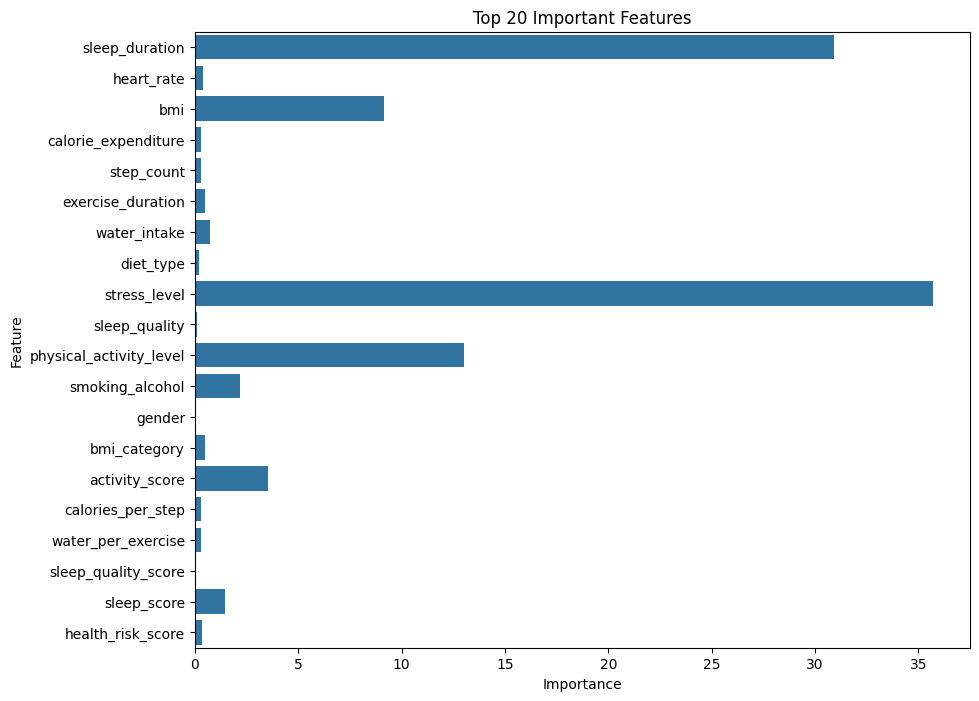

In [186]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(20),
    x='Importance',
    y='Feature'
)

plt.title("Top 20 Important Features")
plt.show()

In [187]:
test_pred = model.predict(test_model)

In [188]:
print(test_pred[:5])

[['unhealthy']
 ['at-risk']
 ['at-risk']
 ['at-risk']
 ['unhealthy']]


In [189]:
submission = pd.DataFrame({
    'id': test['id'],
    'health_condition': test_pred.flatten()
})

In [190]:
submission.head()

,id,health_condition
0,690088,unhealthy
1,690089,at-risk
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy


In [191]:
submission['health_condition'].value_counts()

,count
health_condition,
at-risk,260921
unhealthy,19835
fit,14997


In [192]:
submission.to_csv(
    'my_submission.csv',
    index=False
)

In [193]:
saved_file = pd.read_csv('my_submission.csv')
saved_file.head()


,id,health_condition
0,690088,unhealthy
1,690089,at-risk
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy
